In [123]:
import tensorflow as tf
from keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import Embedding,Dense,SimpleRNN,Dropout

In [124]:
from keras.datasets import imdb
data=imdb.load_data(num_words=10000)

In [125]:
(X_train,y_train),(X_test,y_test)=data
X_train=pad_sequences(X_train,padding='post',maxlen=500)
X_test=pad_sequences(X_test,padding='post',maxlen=500)
X_train.shape



(25000, 500)

In [126]:
model = Sequential([
    Input(shape=(500,)),
    Embedding(input_dim=10000, output_dim=32, mask_zero=True),
    SimpleRNN(64),
    Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_16 (Embedding)        │ (None, 500, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_11 (SimpleRNN)       │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 326,273 (1.24 MB)

 Trainable params: 326,273 (1.24 MB)

 Non-trainable params: 0 (0.00 B)

In [127]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [128]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    min_delta=0.001,
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 45ms/step - accuracy: 0.6223 - loss: 0.6279 - val_accuracy: 0.7475 - val_loss: 0.5194
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.7177 - loss: 0.5588 - val_accuracy: 0.6542 - val_loss: 0.6085
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.7873 - loss: 0.4671 - val_accuracy: 0.6132 - val_loss: 0.6439
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 42ms/step - accuracy: 0.7892 - loss: 0.4503 - val_accuracy: 0.8030 - val_loss: 0.4614
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.8269 - loss: 0.3901 - val_accuracy: 0.7762 - val_loss: 0.5080
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.8526 - loss: 0.3383 - val_accuracy: 0.6825 - val_loss: 0.6209
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.8097 - loss: 0.4045 - val_accuracy: 0.7189 - val_loss: 0.5779
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.8937 - loss: 0.2696 - 

In [129]:
model.evaluate(X_test, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8086 - loss: 0.5148


[0.5147995352745056, 0.8086400032043457]

In [130]:
y_pred=model.predict(X_test)
y_pred=(y_pred>=0.5).astype("int32")

print(y_pred.min())
print(y_pred.max())
print(y_pred.mean())

782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step
0
1
0.51776


In [133]:
count=0
for i in y_pred:
  if i==0:
    count=count+1
print(count)

12056


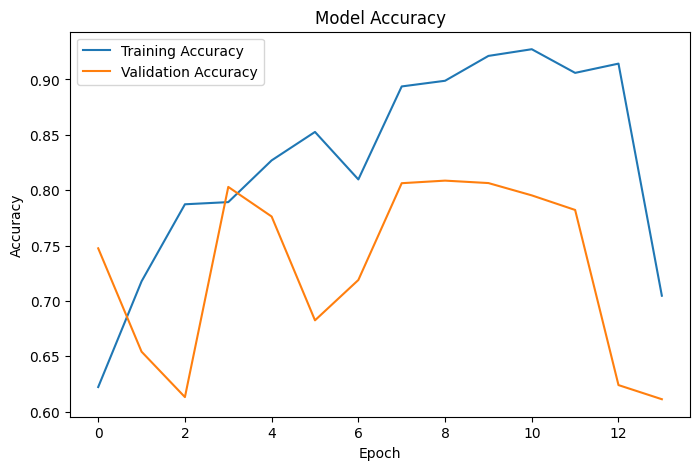

In [134]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model Accuracy")
plt.legend()
plt.show()

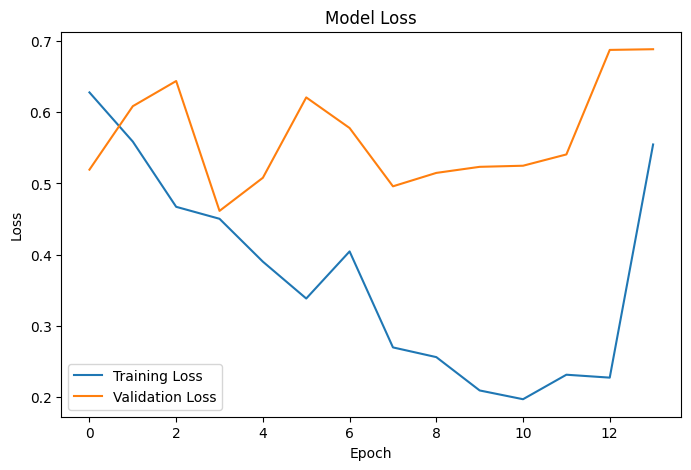

In [135]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model Loss")
plt.legend()
plt.show()